# Processamento Sísmica de Refração

Este Jupyter Notebook permite realizar o processamento de dados de sísmica de refração do exercício dado em aula. Note que este exerício foi utilizado para um modelo de duas camadas. Para um modelos de três camadas ou mais, o processamento é muito parecido, exceto para o cálculo de profundidade.

### Modelo de 2 camadas

\begin{equation*}
\begin{aligned}
v_1 &= \frac{\Delta x}{\Delta t} \\
v_2 &= \frac{\Delta x}{\Delta t} \\
t_i &= t - \frac{x}{v_2} \\
h &= \frac{t_i \cdot v_1 \cdot v_2}{2 \sqrt{v_2^2 - v_1^2}}
\end{aligned}
\end{equation*}

### Modelo de 3 camadas

\begin{equation*}
\begin{aligned}
t_{i1} &= t - \frac{x}{v_2} \\
h_1 &= \frac{t_{i1} \cdot v_1 \cdot v_2}{2 \sqrt{v_2^2 - v_1^2}} \\
t_{i2} &= t - \frac{x}{v_3} \\
h_2 &= h_1 + \frac{t' \cdot v_2 \cdot v_3}{2 \sqrt{v_3^2 - v_2^2}}
\end{aligned}
\end{equation*}

Caso for do seu interesse, crie os códigos necessários para o cálculo de mais camadas. 


In [105]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline

### Lendo arquivo

Crie um arquivo .txt ou .csv com a tabela de tempos de chegada

In [32]:
df = pd.read_csv('exercicio.csv', sep=';', decimal=',')
df

,pos_m,t1_ms,t2_ms
0,0,5.0,83.0
1,3,5.0,81.0
2,6,14.0,80.0
3,9,22.0,79.0
4,12,30.0,77.0
5,15,39.0,74.0
6,18,48.0,72.0
7,21,56.0,70.0
8,24,58.0,68.0
9,27,60.0,65.0


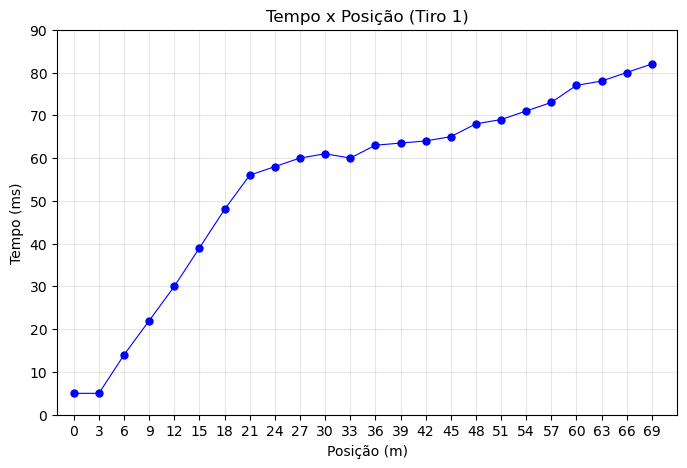

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(df['pos_m'], df['t1_ms'], '.-', markersize=10, color='blue', linewidth=0.8)
plt.xlabel('Posição (m)')
plt.ylabel('Tempo (ms)')
plt.title('Tempo x Posição (Tiro 1)')

plt.ylim(0, 90)
plt.xlim(-2,72)
plt.xticks(np.arange(0, 70, step=3))
plt.grid(True, alpha=0.3)
plt.show()


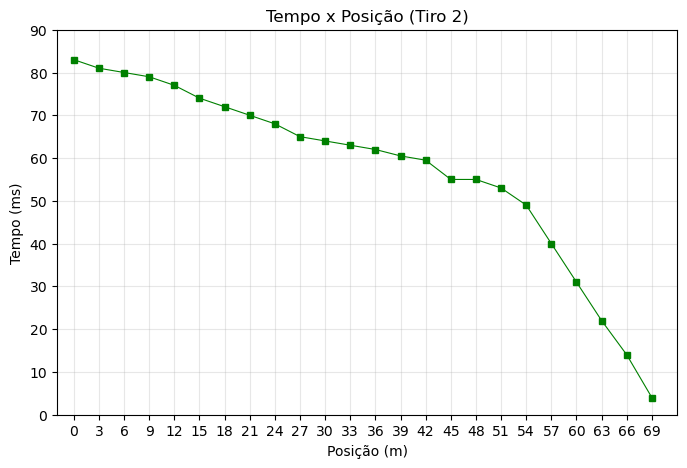

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(df['pos_m'], df['t2_ms'], 's-', markersize=5, color='green', linewidth=0.8)
plt.xlabel('Posição (m)')
plt.ylabel('Tempo (ms)')
plt.title('Tempo x Posição (Tiro 2)')

plt.ylim(0, 90)
plt.xlim(-2,72)
plt.xticks(np.arange(0, 70, step=3))
plt.grid(True, alpha=0.3)
plt.show()


# Cálculos

### Tiro 1

In [116]:
# Cálculo de V1
v1_t1 = (df.iloc[6]['pos_m'] - df.iloc[1]['pos_m']) / (df.iloc[6]['t1_ms'] - df.iloc[1]['t1_ms'])
print(f'Pontos selecionados: {df.iloc[6]["pos_m"]}, {df.iloc[1]["pos_m"]}')
print(f'Velocidade de camada 1: {v1_t1:.3f} Km/s')

Pontos selecionados: 18.0, 3.0
Velocidade de camada 1: 0.349 Km/s


In [117]:
# Cálculo de V2
v2_t1 = (df.iloc[23]['pos_m'] - df.iloc[10]['pos_m']) / (df.iloc[23]['t1_ms'] - df.iloc[10]['t1_ms'])
print(f'Pontos selecionados: {df.iloc[23]["pos_m"]}, {df.iloc[10]["pos_m"]}')
print(f'Velocidade de camada 1: {v2_t1:.3f} Km/s')


Pontos selecionados: 69.0, 30.0
Velocidade de camada 1: 1.857 Km/s


In [119]:
# Cálculo do ti
ti_1 = df.iloc[21]['t1_ms'] - (df.iloc[21]['pos_m'] / v2_t1)
print(f'O valor de ti no tiro 1 é de {ti_1:.3f}')

O valor de ti no tiro 1 é de 44.077


In [142]:
# Cálculo de profundidade
def profundidade(ti, v1, v2):
    h = (ti * v1 * v2) / (2*math.sqrt(v2**2 - v1**2))
    print(f'A profundidade da camada é de {h:.3f} metros.')
    
    return h

In [143]:
h1 = profundidade(ti_1, v1_t1, v2_t1)

A profundidade da camada é de 7.827 metros.


### Tiro 2

In [145]:
# Cálculo de V1
v1_t2 = (df.iloc[23]['pos_m'] - df.iloc[19]['pos_m']) / (df.iloc[19]['t2_ms'] - df.iloc[23]['t2_ms'])
print(f'Pontos selecionados: {df.iloc[19]["pos_m"]}, {df.iloc[19]['t2_ms']}, {df.iloc[23]["pos_m"]}')
print(f'Velocidade de camada 1: {v1_t2:.3f} Km/s')

Pontos selecionados: 57.0, 40.0, 69.0
Velocidade de camada 1: 0.333 Km/s


In [146]:
# Cálculo de V2
v2_t2 = (df.iloc[14]['pos_m'] - df.iloc[1]['pos_m']) / (df.iloc[1]['t2_ms'] - df.iloc[14]['t2_ms'])
print(f'Pontos selecionados: {df.iloc[1]["pos_m"]}, {df.iloc[14]["pos_m"]}')
print(f'Velocidade de camada 2: {v2_t2:.3f} Km/s')


Pontos selecionados: 3.0, 42.0
Velocidade de camada 2: 1.814 Km/s


In [147]:
# Cálculo do ti
ti_2 = df.iloc[12]['t2_ms'] - (df.iloc[12]['pos_m'] / v2_t2)
print(f'O valor de ti no tiro 2 é de {ti_2:.3f}')

O valor de ti no tiro 2 é de 42.154


In [148]:
h2 = profundidade(ti_2, v1_t2, v2_t2)

A profundidade da camada é de 7.147 metros.


### Gráfico final e Modelo Geológico

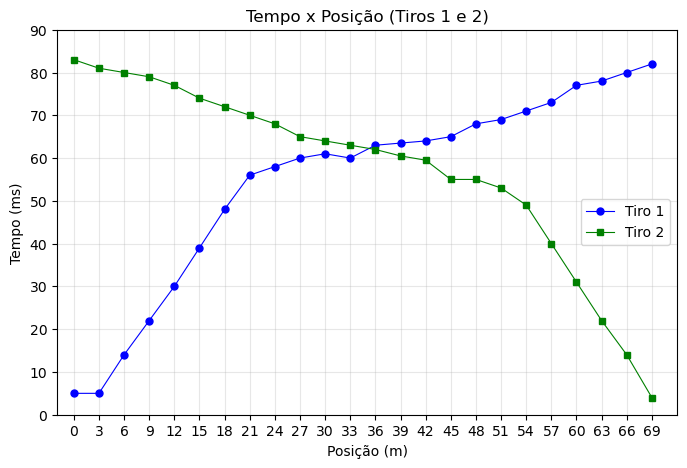

In [136]:
fig, ax = plt.subplots(figsize=(8 ,5))

ax.plot(df['pos_m'], df['t1_ms'], '.-', markersize=10, color='blue', linewidth=0.8, label='Tiro 1')
ax.plot(df['pos_m'], df['t2_ms'], 's-', markersize=5, color='green', linewidth=0.8, label='Tiro 2')

ax.set_title('Tempo x Posição (Tiros 1 e 2)')
ax.set_xlabel('Posição (m)')
ax.set_ylabel('Tempo (ms)')
ax.set_xlim(-2, 72)
ax.set_ylim(0, 90)
ax.set_xticks(np.arange(0, 70, step=3))

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


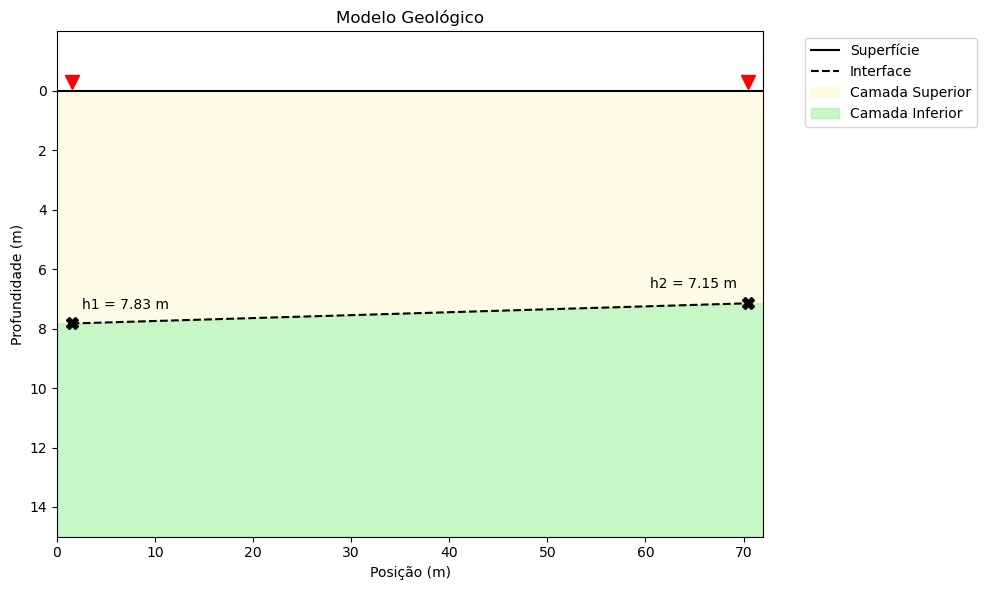

In [178]:
# Modelo Geológico
# Posições dos pontos de tiro
tiro_1_pos = 1.5  # m
tiro_2_pos = 70.5  # m

# Limites do modelo
x_min, x_max = 0, 72  # m (para cobrir os pontos de tiro)
y_max = 15  # Profundidade máxima em m

# Criando o modelo
fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(y=0, color='black', linewidth=1.5, label='Superfície')

x_points = [tiro_1_pos, tiro_2_pos]
y_points = [h1, h2]
ax.plot(tiro_1_pos, h1, 'X', color='black', markersize=8)
ax.plot(tiro_2_pos, h2, 'X', color='black', markersize=8)
ax.plot(x_points, y_points, '--', color='black', linewidth=1.5, label='Interface')

ax.plot(tiro_1_pos, -0.3, 'v', color='red', markersize=10)
ax.plot(tiro_2_pos, -0.3, 'v', color='red', markersize=10)

x_fill = np.linspace(x_min, x_max, 100)
y_interface = np.interp(x_fill, x_points, y_points)  # Interpolação linear entre h1 e h2
ax.fill_between(x_fill, 0, y_interface, color='lemonchiffon', alpha=0.5, label='Camada Superior')
# Camada inferior (interface até o limite de 15 m)
ax.fill_between(x_fill, y_interface, y_max, color='lightgreen', alpha=0.5, label='Camada Inferior')

ax.annotate(f'h1 = {h1:.2f} m', (tiro_1_pos + 1, h1 - 0.5), fontsize=10)
ax.annotate(f'h2 = {h2:.2f} m', (tiro_2_pos - 10, h2 - 0.5), fontsize=10)

ax.set_xlabel('Posição (m)')
ax.set_ylabel('Profundidade (m)')
ax.set_title('Modelo Geológico')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, -2)  # Inverter o eixo y (0 na superfície, 15 no fundo)
ax.set_yticks(np.arange(0, y_max + 1, step=2))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

